In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_master = pd.read_csv(r"../data/cleaned/df_master_feature_engineered.csv")

df_master.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'price_capped',
       'freight_value_capped', 'customer_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'total_payment_value',
       'max_installments', 'primary_payment_type', 'payment_sequential',
       'avg_review_score', 'review_count', 'delivery_time_days',
       'shipping_duration_days', 'order_processing_time_days',
       'tota

In [3]:
#capping the oulier for the delivery time

In [4]:
Q1 = df_master["delivery_time_days"].quantile(0.25)
Q3 = df_master["delivery_time_days"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_master["delivery_time_days"] = df_master["delivery_time_days"].clip(lower=lower, upper=upper)


Text(0.5, 1.0, 'Price (Raw / Before Capping)')

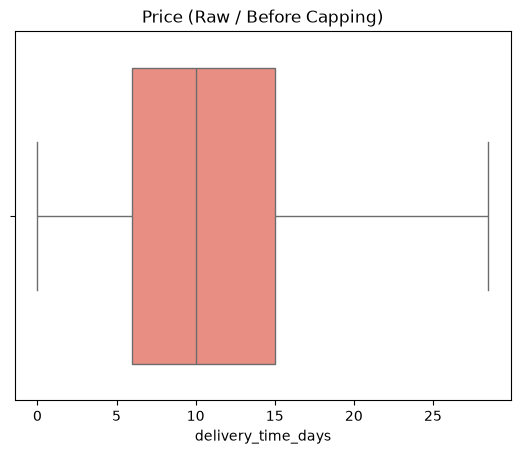

In [5]:
sns.boxplot(x=df_master['delivery_time_days'], color='salmon').set_title('Price (Raw / Before Capping)')

In [6]:
#sales analysis

In [7]:
#converting the dtype of date cols

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    df_master[col] = pd.to_datetime(df_master[col])
    print(df_master[col].dtype)

datetime64[us]
datetime64[us]
datetime64[us]
datetime64[us]
datetime64[us]


In [8]:
#grouped monthly sales 
monthly_sales = (df_master.groupby('sales_month')['monthly_sales'].first().reset_index())

monthly_sales

,sales_month,monthly_sales
0,2016-09,343.02
1,2016-10,61746.94
2,2016-12,19.62
3,2017-01,176376.56
4,2017-02,323815.95
5,2017-03,505735.83
6,2017-04,456108.32
7,2017-05,701119.60
8,2017-06,585400.98
9,2017-07,716069.98


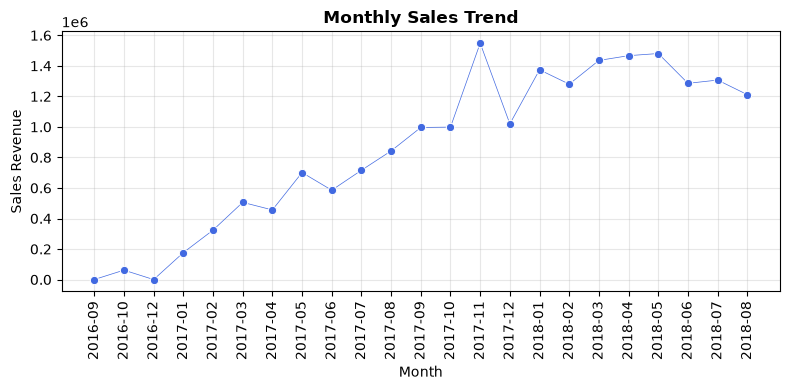

In [9]:
#monthly sales trend

## Observation

"""- The monthly sales trend illustrates changes in revenue over time.
- Certain months generated significantly higher sales than others, indicating periods of increased customer demand.
- Lower revenue months may reflect seasonal fluctuations or reduced purchasing activity.
- This analysis helps identify business growth patterns and supports future sales forecasting."""

plt.figure(figsize=(8,4))

sns.lineplot(data=monthly_sales,x="sales_month",y="monthly_sales",marker="o",linewidth=0.5,color="royalblue")

plt.title("Monthly Sales Trend", fontsize=12, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Sales Revenue")

plt.xticks(rotation=90)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../static/images/monthly_sales.png", dpi=300, bbox_inches="tight")

plt.show()

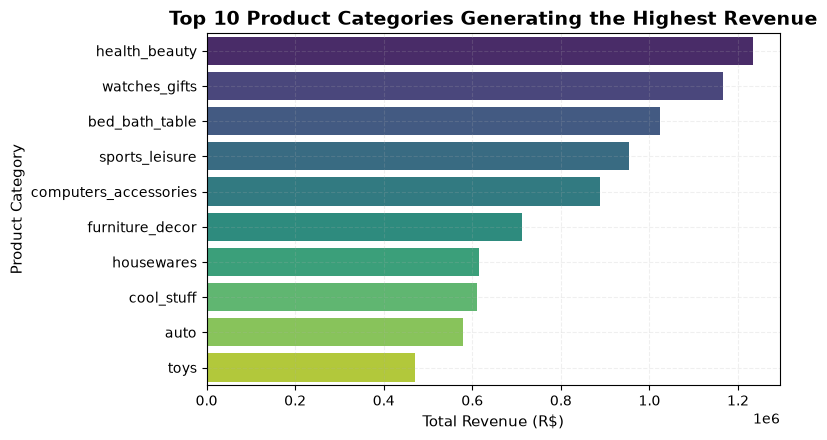

In [10]:
# Revenue by Product Category Ranking
category_revenue = df_master.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False).reset_index()
top10_category = category_revenue.head(10)

plt.figure(figsize=(8,4.5))

# Optimized Horizontal Bar Chart: Essential for handling long text category labels seamlessly
sns.barplot(
    data=top10_category, 
    x="price", 
    y="product_category_name_english", 
    hue="product_category_name_english", 
    palette="viridis", 
    legend=False)

plt.title("Top 10 Product Categories Generating the Highest Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue (R$)", fontsize=11)
plt.ylabel("Product Category", fontsize=11)
plt.grid(True, alpha=0.2, linestyle="--")

plt.tight_layout()
plt.savefig("../static/images/revenue_category.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\rizwa\AppData\Local\Temp\ipykernel_4664\4247163505.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=state_revenue,x="price",y="customer_state",palette="viridis")


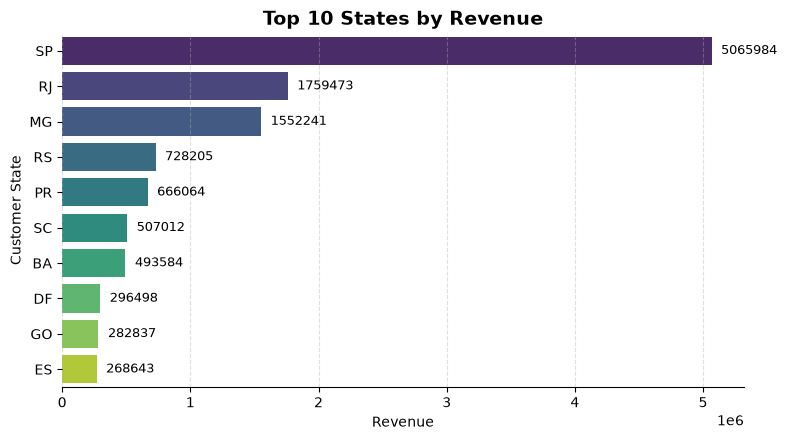

In [11]:
# Revenue by State

state_revenue = (df_master.groupby("customer_state")["price"].sum().sort_values(ascending=False).head(10).reset_index())

plt.figure(figsize=(8,4.5))

ax = sns.barplot(data=state_revenue,x="price",y="customer_state",palette="viridis")

# Revenue labels
for container in ax.containers:
    ax.bar_label(container, fmt=" %.0f", padding=4, fontsize=9)

plt.title("Top 10 States by Revenue",fontsize=14,fontweight="bold")

plt.xlabel("Revenue")
plt.ylabel("Customer State")

plt.grid(axis="x", linestyle="--", alpha=0.4)

sns.despine(left=True)

plt.tight_layout()

plt.savefig("../static/images/revenue_state.png",dpi=300,bbox_inches="tight")

plt.show()

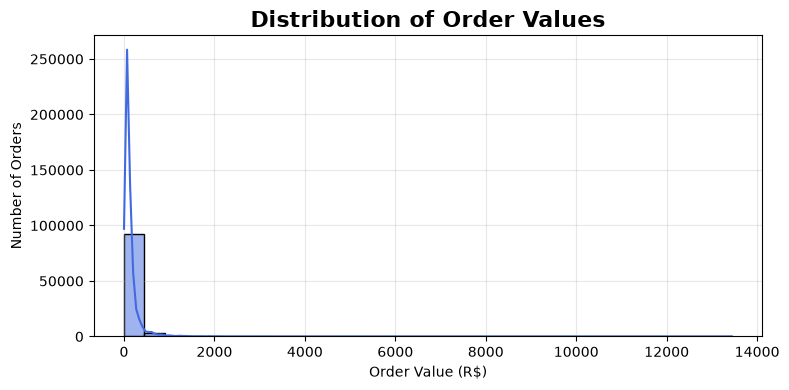

In [12]:
#average order value

# Step 1: Calculate total value for each order
order_value = (df_master.groupby("order_id")["price"].sum().reset_index())

# Rename the column
order_value.rename(columns={"price": "order_value"}, inplace=True)

# Display first few rows
order_value.head()

average_order_value = order_value["order_value"].mean()

plt.figure(figsize=(8,4))

sns.histplot(data=order_value,x="order_value",bins=30,kde=True,color="royalblue")

plt.grid(alpha=0.3)
plt.title("Distribution of Order Values", fontsize=16, fontweight="bold")
plt.xlabel("Order Value (R$)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.savefig("../static/images/average_order_value.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
#customer analysis

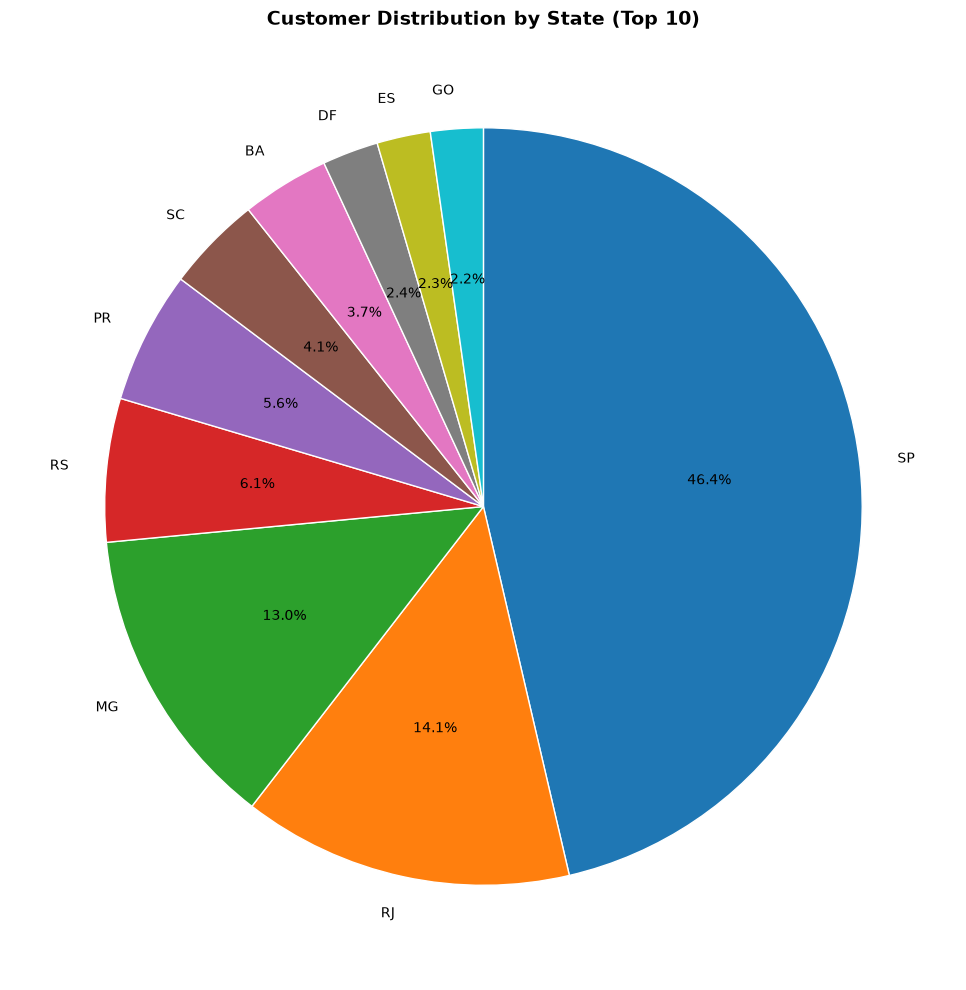

In [14]:
# Customer Distribution by State

customer_distribution = (
    df_master.groupby("customer_state")["customer_unique_id"].nunique().sort_values(ascending=False)
    .head(10).reset_index(name="customer_count"))

plt.figure(figsize=(10,10))

plt.pie(customer_distribution["customer_count"],labels=customer_distribution["customer_state"],
    autopct="%1.1f%%",startangle=90,
    counterclock=False,wedgeprops={"edgecolor": "white"})

plt.title("Customer Distribution by State (Top 10)",fontsize=14,fontweight="bold")

plt.tight_layout()

plt.savefig("../static/images/customer_distribution.png",dpi=300,bbox_inches="tight")

plt.show()

In [15]:
#repeat coustomers 

# Count repeat vs one-time customers
repeat_customer = (df_master["repeat_customer_indicator"].value_counts().reset_index())

repeat_customer.columns = ["Customer Type","Number of Customers"]

repeat_customer

,Customer Type,Number of Customers
0,0,102963
1,1,7211


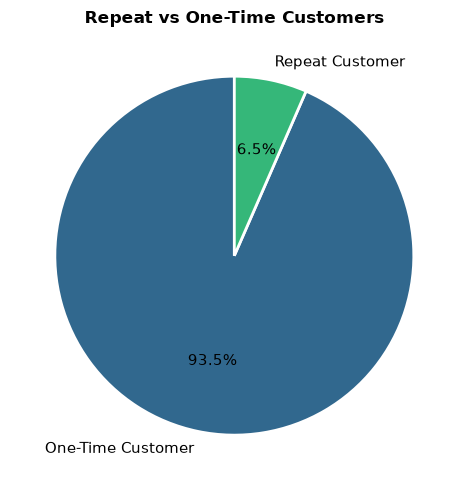

In [16]:
# Count repeat and one-time customers
repeat_customer = (
    df_master["repeat_customer_indicator"].replace({
        0: "One-Time Customer",
        1: "Repeat Customer"})
    .value_counts()
    .reset_index()
)

repeat_customer.columns = ["Customer Type","Number of Customers"]

# Pie Chart
plt.figure(figsize=(8,5))

plt.pie(
    repeat_customer["Number of Customers"],
    labels=repeat_customer["Customer Type"],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("viridis", len(repeat_customer)),
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11}
)

plt.title(
    "Repeat vs One-Time Customers",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("../static/images/repeat_customers.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
#top purchasing cities

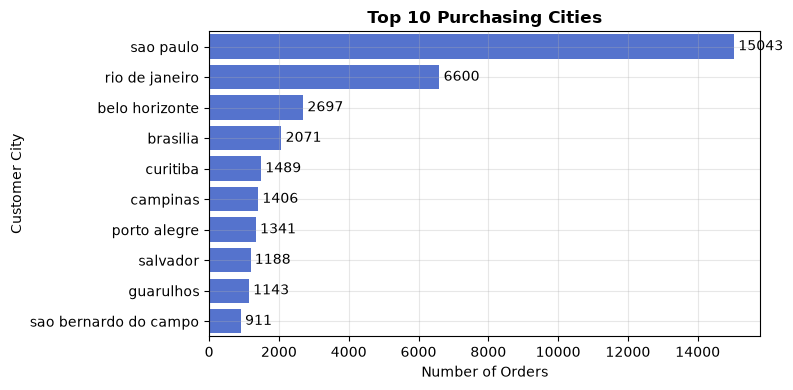

In [18]:
# Count unique orders for each city
city_orders = (df_master.groupby("customer_city")["order_id"].nunique().sort_values(ascending=False).reset_index())

# Top 10 cities
top10_cities = city_orders.head(10)

# Plot
plt.figure(figsize=(8,4))

ax = sns.barplot( data=top10_cities,x="order_id",y="customer_city",color="royalblue")

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Top 10 Purchasing Cities", fontsize=12, fontweight="bold")
plt.xlabel("Number of Orders")
plt.ylabel("Customer City")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../static/images/top_purchasing_cities.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
#customer spendings

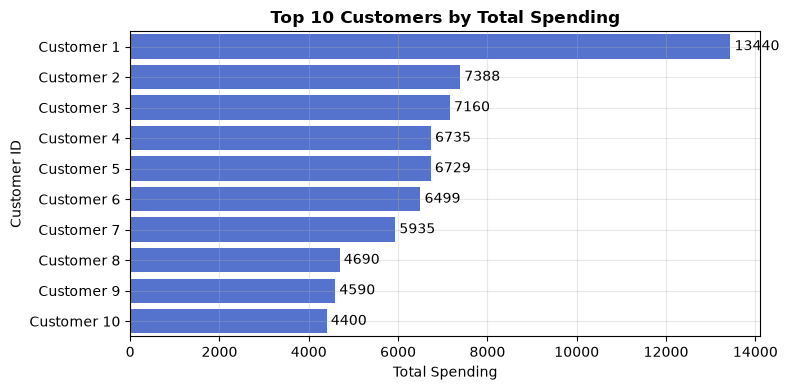

In [20]:
# Total spending by each customer
customer_spending = (
    df_master.groupby("customer_unique_id")["price"].sum().sort_values(ascending=False).reset_index())

# Rename column
customer_spending.rename(columns={"price": "total_spending"},inplace=True)

# Top 10 customers
top10_customers = customer_spending.head(10)

top10_customers["Rank"] = [
    "Customer 1", "Customer 2", "Customer 3",
    "Customer 4", "Customer 5", "Customer 6",
    "Customer 7", "Customer 8", "Customer 9",
    "Customer 10"
]

# Plot
plt.figure(figsize=(8,4))

ax = sns.barplot(data=top10_customers,x="total_spending",y="Rank",color="royalblue")

# Value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.title("Top 10 Customers by Total Spending", fontsize=12, fontweight="bold")
plt.xlabel("Total Spending")
plt.ylabel("Customer ID")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../static/images/customer_spending.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
#product analysis

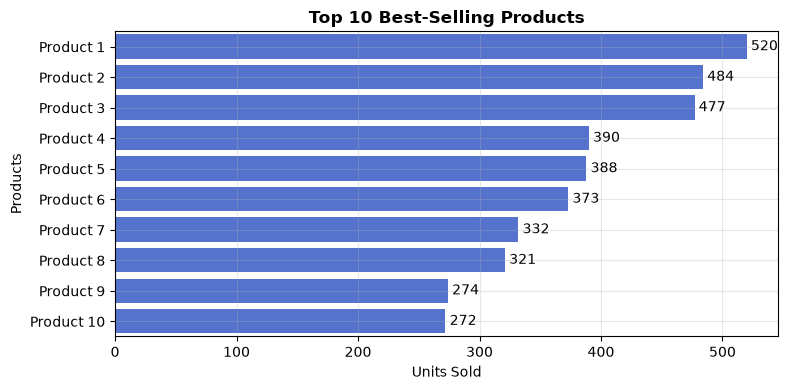

In [22]:
#best selling analysis
# Count how many times each product was sold
best_selling_products = (df_master.groupby("product_id")["order_item_id"].count().sort_values(ascending=False)
    .reset_index())

# Rename column
best_selling_products.rename(columns={"order_item_id": "units_sold"},inplace=True)

# Top 10 products
top10_products = best_selling_products.head(10).copy()

# Create custom labels
top10_products["Product"] = [f"Product {i}" for i in range(1, len(top10_products)+1)]

# Plot
plt.figure(figsize=(8,4))

ax = sns.barplot( data=top10_products, x="units_sold", y="Product", color="royalblue")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Top 10 Best-Selling Products", fontsize=12, fontweight="bold")
plt.xlabel("Units Sold")
plt.ylabel("Products")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../static/images/best_selling_products.png", dpi=300, bbox_inches="tight")
plt.show()

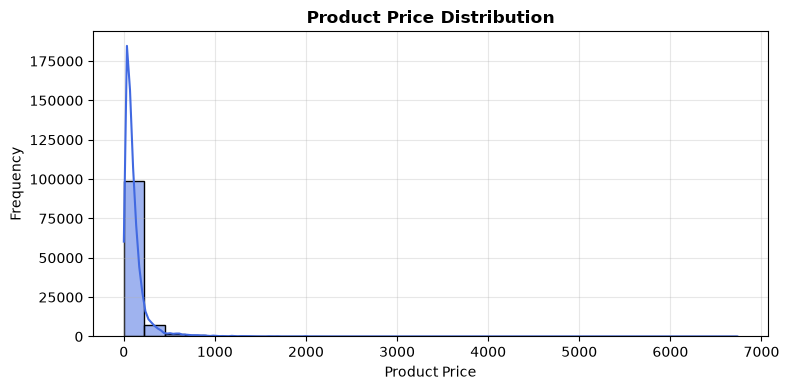

In [23]:
#product price distribution

plt.figure(figsize=(8,4))

sns.histplot(data=df_master,x="price",bins=30,kde=True,color="royalblue")

plt.title("Product Price Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Product Price")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../static/images/product_pricing.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
## Observation

"""- Most products are concentrated in the lower price range.
- The distribution is right-skewed, indicating that high-priced products are relatively rare."""

'- Most products are concentrated in the lower price range.\n- The distribution is right-skewed, indicating that high-priced products are relatively rare.'

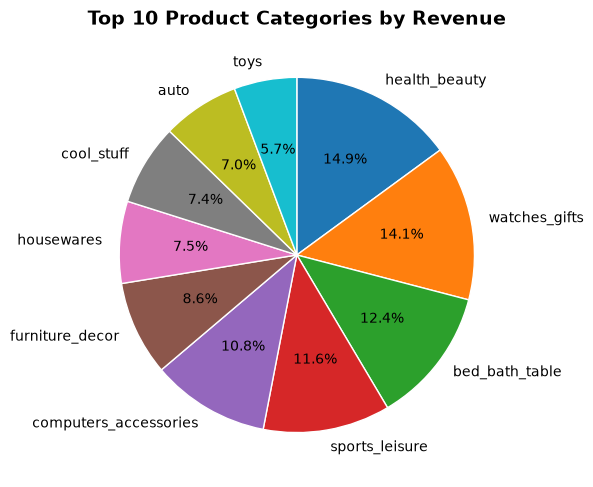

In [25]:
#product popularity
# Revenue by Product Category (Top 10)

category_revenue = (
    df_master.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False).head(10)
    .reset_index(name="revenue"))

plt.figure(figsize=(6,8))

plt.pie(
    category_revenue["revenue"],
    labels=category_revenue["product_category_name_english"],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white"}
)

plt.title(
    "Top 10 Product Categories by Revenue",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../static/images/category_performance.png",dpi=300,bbox_inches="tight")

plt.show()

In [26]:
#seller analysis

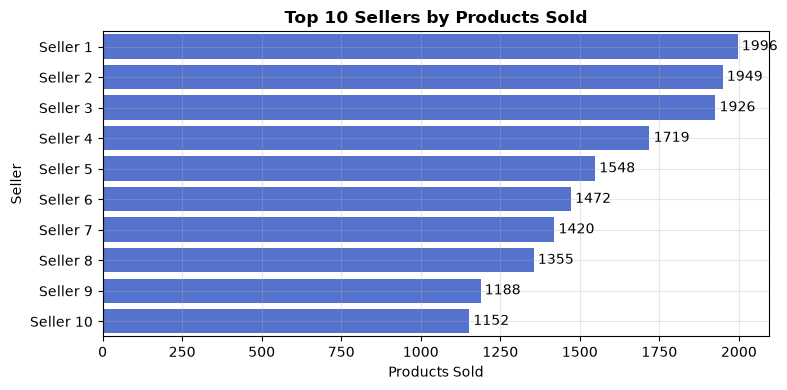

In [27]:
#top 10 seller

# Count products sold by each seller
top_sellers = (df_master.groupby("seller_id")["order_item_id"].count().sort_values(ascending=False).reset_index())

# Rename column
top_sellers.rename(columns={"order_item_id": "products_sold"},inplace=True)

# Top 10 sellers
top10_sellers = top_sellers.head(10).copy()

# Create custom labels
top10_sellers["Seller"] = [f"Seller {i}" for i in range(1, len(top10_sellers)+1)]

# Plot
plt.figure(figsize=(8,4))

ax = sns.barplot(data=top10_sellers,x="products_sold",y="Seller",color="royalblue")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Top 10 Sellers by Products Sold", fontsize=12, fontweight="bold")
plt.xlabel("Products Sold")
plt.ylabel("Seller")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../static/images/top_sellers.png", dpi=300, bbox_inches="tight")
plt.show()

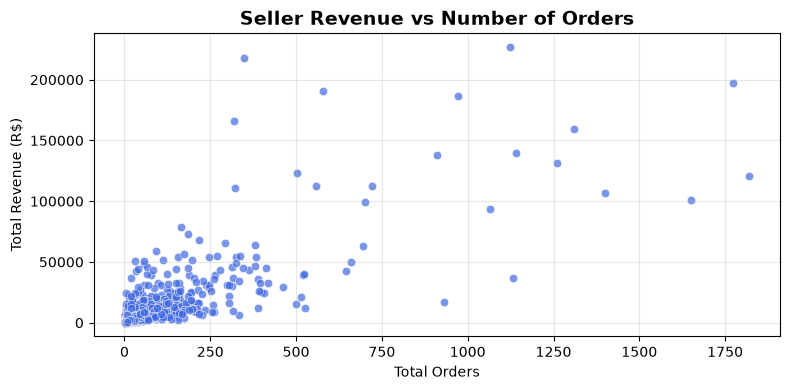

In [28]:
#revenue by seller

# Revenue vs Orders by Seller

seller_analysis = (
    df_master
    .groupby("seller_id")
    .agg(
        total_revenue=("price", "sum"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

plt.figure(figsize=(8,4))

sns.scatterplot(
    data=seller_analysis,
    x="total_orders",
    y="total_revenue",
    color="royalblue",
    alpha=0.7)

plt.title(
    "Seller Revenue vs Number of Orders",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Total Orders")
plt.ylabel("Total Revenue (R$)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../static/images/revenue_by_seller.png", dpi=300, bbox_inches="tight")
plt.show()

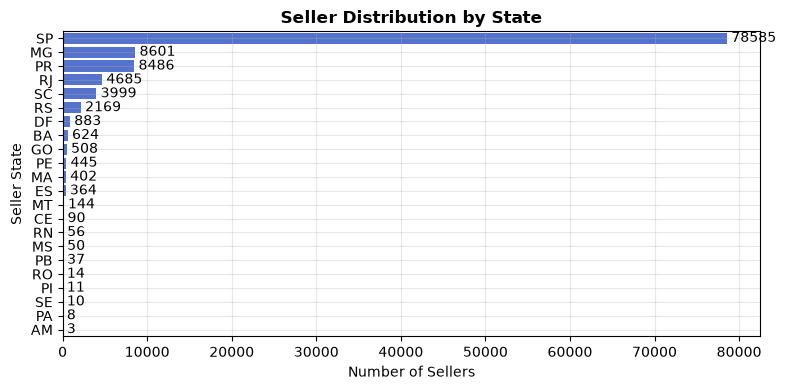

In [29]:
#seller location

plt.figure(figsize=(8,4))

ax = sns.countplot(data=df_master,y="seller_state",order=df_master["seller_state"].value_counts().index,color="royalblue")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Seller Distribution by State", fontsize=12, fontweight="bold")
plt.xlabel("Number of Sellers")
plt.ylabel("Seller State")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../static/images/seller_locations.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\rizwa\AppData\Local\Temp\ipykernel_4664\1124066654.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


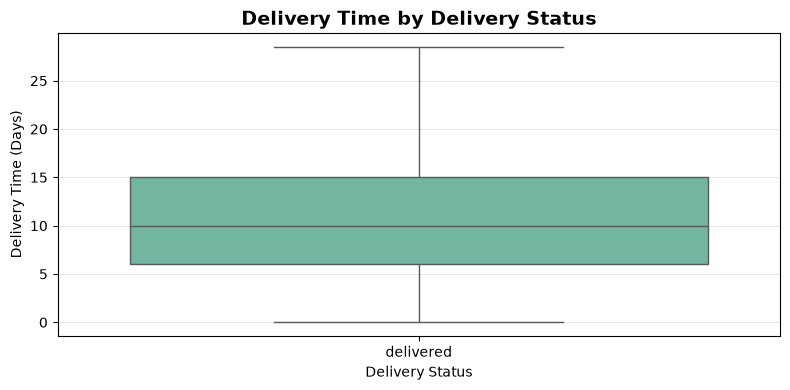

In [30]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df_master,
    x="order_status",
    y="delivery_time_days",
    palette="Set2"
)

plt.title(
    "Delivery Time by Delivery Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Delivery Status")
plt.ylabel("Delivery Time (Days)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../static/images/seller_delivery_performance.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
#delivry analysis

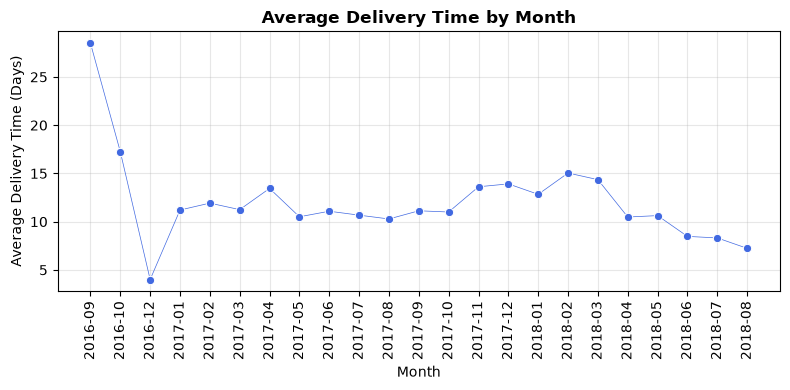

In [32]:
#average delivry time by month
delivery_trend = (df_master.groupby("sales_month")["delivery_time_days"].mean().reset_index())

plt.figure(figsize=(8,4))

sns.lineplot(data=delivery_trend,x="sales_month",y="delivery_time_days",marker="o",linewidth=0.5,
    color="royalblue")

plt.title("Average Delivery Time by Month", fontsize=12, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Average Delivery Time (Days)")

plt.xticks(rotation=90)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../static/images/average_delivery_time.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
#add delivery sts col
df_master["delivery_status"] = np.where(
    df_master["order_delivered_customer_date"] <= df_master["order_estimated_delivery_date"],"On Time","Delayed")

df_master["delivery_status"]

0         On Time
1         On Time
2         On Time
3         On Time
4         On Time
           ...   
110169    On Time
110170    On Time
110171    On Time
110172    On Time
110173    On Time
Name: delivery_status, Length: 110174, dtype: str

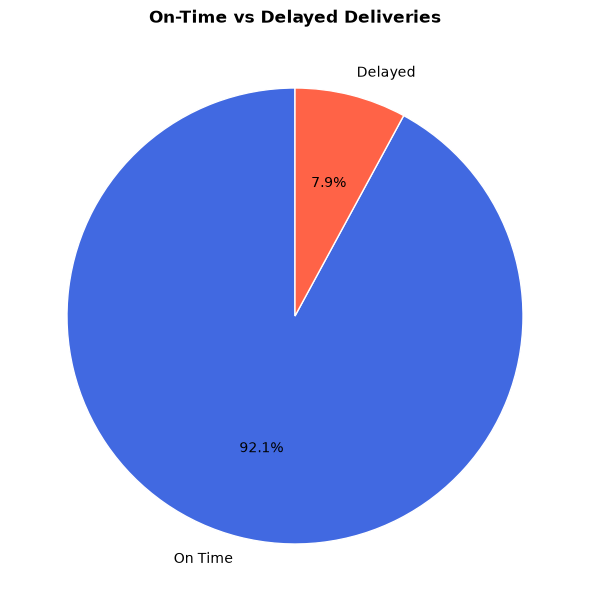

In [34]:
delivery_status = df_master["delivery_status"].value_counts()

plt.figure(figsize=(6,8))

plt.pie(
    delivery_status,
    labels=delivery_status.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["royalblue", "tomato"],
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)

plt.title(
    "On-Time vs Delayed Deliveries",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("../static/images/delayed_deliveries.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
Q1 = df_master["shipping_duration_days"].quantile(0.25)
Q3 = df_master["shipping_duration_days"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_master["shipping_duration_days"] = df_master["shipping_duration_days"].clip(lower=lower, upper=upper)

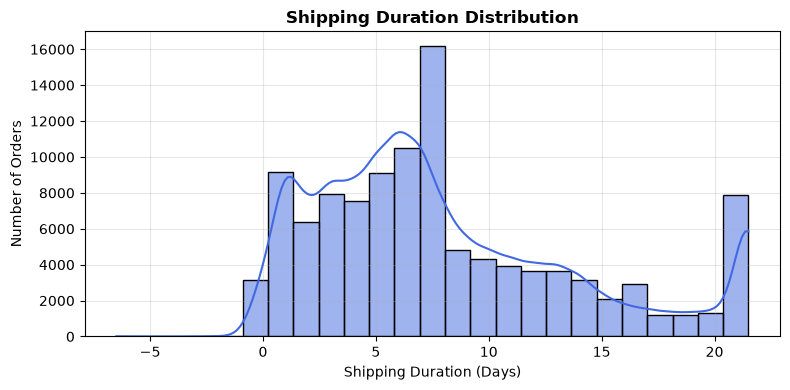

'## Observation\n\n- The histogram shows the distribution of shipping durations across all orders.\n- Most orders were shipped within a few days after approval.\n- The distribution is positively skewed, indicating that longer shipping durations occur less frequently.\n- A small number of orders experienced unusually long shipping times, suggesting occasional operational or logistics delays.'

In [36]:
#shipping performance
plt.figure(figsize=(8,4))

sns.histplot(data=df_master,x="shipping_duration_days",bins=25,kde=True,color="royalblue")

plt.title("Shipping Duration Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Shipping Duration (Days)")
plt.ylabel("Number of Orders")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../static/images/shipping_performance.png", dpi=300, bbox_inches="tight")
plt.show()

"""## Observation

- The histogram shows the distribution of shipping durations across all orders.
- Most orders were shipped within a few days after approval.
- The distribution is positively skewed, indicating that longer shipping durations occur less frequently.
- A small number of orders experienced unusually long shipping times, suggesting occasional operational or logistics delays."""

In [37]:
#payment analysis

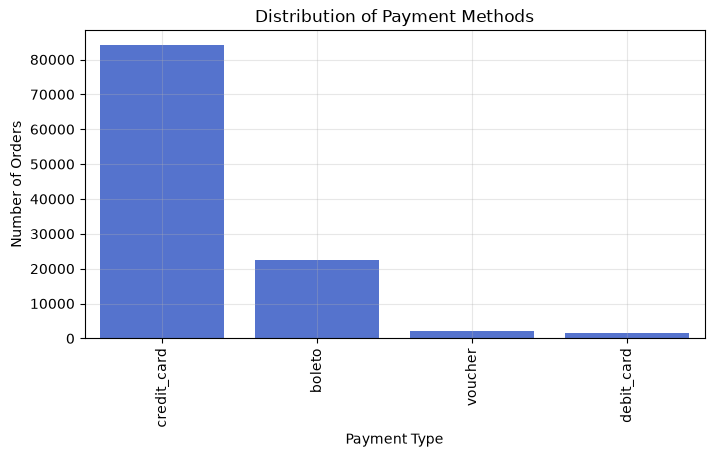

In [38]:
#types of payment
plt.figure(figsize=(8,4))
sns.countplot(data=df_master, x="primary_payment_type", order=df_master["primary_payment_type"].value_counts().index,color="royalblue")
plt.title("Distribution of Payment Methods")
plt.xlabel("Payment Type")
plt.ylabel("Number of Orders")
plt.grid(alpha=0.3)
plt.xticks(rotation=90)
plt.savefig("../static/images/payment_methods.png", dpi=300, bbox_inches="tight")
plt.show()

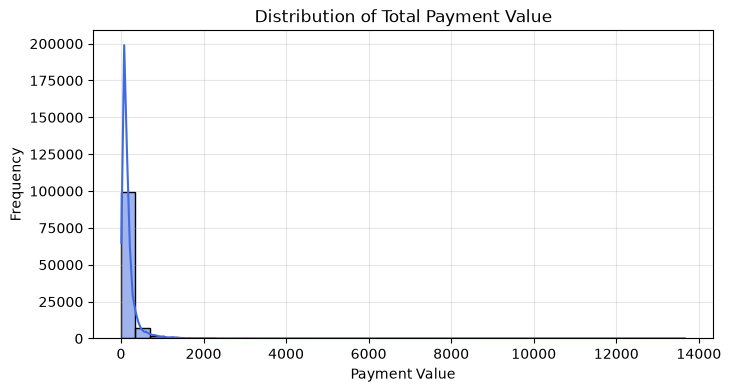

In [39]:
plt.figure(figsize=(8,4))

sns.histplot(df_master["total_payment_value"], bins=40, kde=True,color="royalblue")

plt.title("Distribution of Total Payment Value")
plt.grid(alpha=0.3)
plt.xlabel("Payment Value")
plt.ylabel("Frequency")
plt.savefig("../static/images/payment_value_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

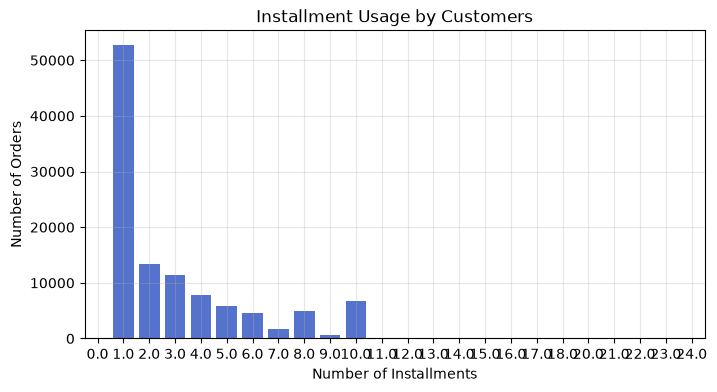

In [40]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df_master,
    x="max_installments",
    order=sorted(df_master["max_installments"].unique()),color="royalblue")

plt.grid(alpha =0.3)
plt.title("Installment Usage by Customers")
plt.xlabel("Number of Installments")
plt.ylabel("Number of Orders")
plt.savefig("../static/images/installment_usage.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
#review analysis

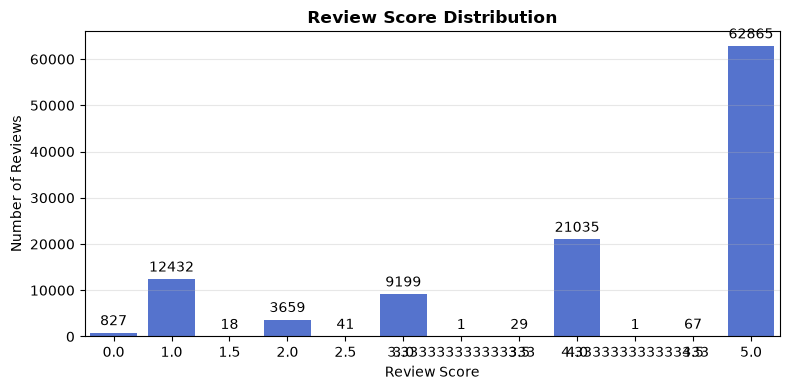

In [42]:
#review distribution
plt.figure(figsize=(8,4))

ax = sns.countplot(data=df_master,x="avg_review_score",color="royalblue")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Review Score Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../static/images/review_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

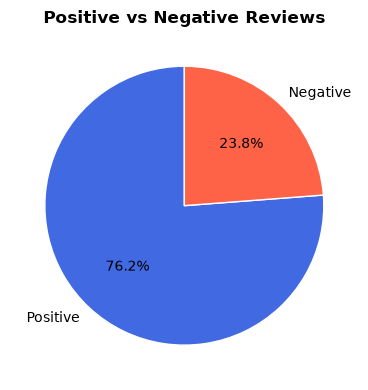

In [43]:
df_master["review_sentiment"] = np.where(
    df_master["avg_review_score"] >= 4,
    "Positive",
    "Negative")

review_sentiment = df_master["review_sentiment"].value_counts()

plt.figure(figsize=(8,4))

plt.pie(
    review_sentiment,
    labels=review_sentiment.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["royalblue", "tomato"],
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)

plt.title("Positive vs Negative Reviews",fontsize=12,fontweight="bold")

plt.tight_layout()
plt.savefig("../static/images/positive_negative_reviews.png", dpi=300, bbox_inches="tight")
plt.show()

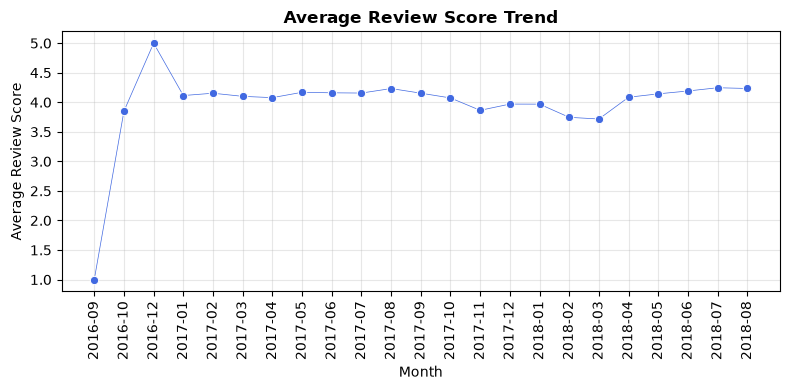

In [44]:
# Create review month
df_master["review_month"] = df_master["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Average review score by month
review_trend = (
    df_master
    .groupby("review_month")["avg_review_score"]
    .mean()
    .reset_index())

# Plot
plt.figure(figsize=(8,4))

sns.lineplot(
    data=review_trend,
    x="review_month",
    y="avg_review_score",
    marker="o",
    linewidth=0.5,
    color="royalblue")

plt.title("Average Review Score Trend", fontsize=12, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Average Review Score")

plt.xticks(rotation=90)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../static/images/review_trend.png", dpi=300, bbox_inches="tight")
plt.show()

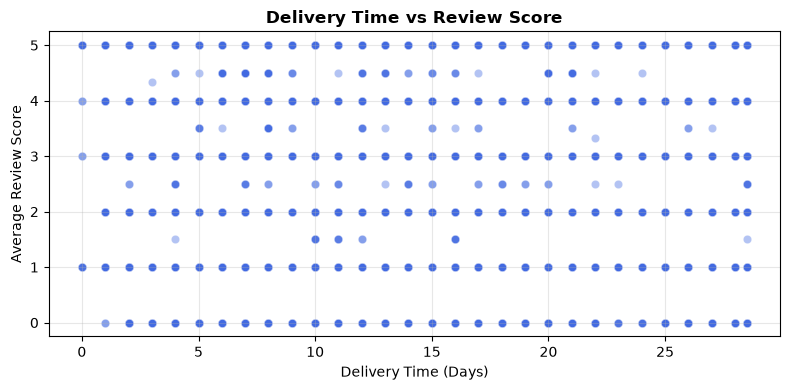

In [45]:
#delivery time review score
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=df_master,
    x="delivery_time_days",
    y="avg_review_score",
    color="royalblue",
    alpha=0.4
)

plt.title("Delivery Time vs Review Score", fontsize=12, fontweight="bold")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Average Review Score")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../static/images/delivery_review_scatter.png",dpi=300,bbox_inches="tight")
plt.show()

In [46]:
df_master.to_csv(
    r"../df_master.csv",
    index=False
)